<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Dengue_Research/blob/main/Dengue_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# **Load The dataset**


In [9]:
print("Reading the real Dengue dataset..")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/Datasets/Dengue/Bagerhat_humi_75.csv')

Reading the real Dengue dataset..
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Prepare Data**

we use PCA principle component analysis algorithm for feature enginnearing.

### Data Inspection and Preprocessing for PCA

Before applying PCA, it's essential to:
1.  **Inspect Data Types and Missing Values**: Understand the structure of the DataFrame and identify any columns with missing data or non-numeric types that need to be handled.
2.  **Handle Missing Values**: PCA is sensitive to missing values, so they must be imputed or rows/columns containing them dropped.
3.  **Select Numerical Features**: PCA operates on numerical data. Non-numerical columns (like 'Date' or 'District') must be excluded or appropriately encoded.
4.  **Scale Features**: PCA is affected by feature scaling. Features with larger variance tend to dominate the principal components. Therefore, it's good practice to standardize the data before applying PCA.

In [10]:
# Display basic information about the DataFrame
print(data.info())

# Display the number of missing values per column
print("\nMissing values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720 entries, 0 to 1719
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           1720 non-null   object 
 1   District                       1720 non-null   object 
 2   temperature_2m_mean            1719 non-null   float64
 3   Temp_Lagwindow_8–14            1706 non-null   float64
 4   Temp_Lagwindow_15–21           1699 non-null   float64
 5   Temp_Lagwindow_22–28           1692 non-null   float64
 6   rain_sum (mm)                  1720 non-null   float64
 7   Rain_15_21_sum                 1699 non-null   float64
 8   Rain_22_28_sum                 1692 non-null   float64
 9   HeavyRain_15_21_days           1699 non-null   float64
 10  HeavyRain_22_28_days           1692 non-null   float64
 11  relative_humidity_2m_mean (%)  1719 non-null   float64
 12  Hum_1–7                        1713 non-null   f

In [11]:
# Drop 'Date' and 'District' columns as they are not suitable for direct PCA and will be handled separately if needed.
# For 'Temp_Lagwindow_8–14', we will fill NaN values with the mean for now.

# Make a copy to avoid modifying the original DataFrame directly for PCA
data_pca = data.copy()

# Convert 'Date' to datetime for potential time-series features later if needed, but drop for PCA
if 'Date' in data_pca.columns:
    data_pca['Date'] = pd.to_datetime(data_pca['Date'])
    data_pca = data_pca.drop('Date', axis=1)

if 'District' in data_pca.columns:
    data_pca = data_pca.drop('District', axis=1)

# Fill missing values in numerical columns with the mean
# Identify numerical columns first
numerical_cols = data_pca.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if data_pca[col].isnull().any():
        data_pca[col] = data_pca[col].fillna(data_pca[col].mean())

print("\nMissing values after imputation:")
print(data_pca.isnull().sum()[data_pca.isnull().sum() > 0])

# Display the first few rows of the preprocessed data
print("\nPreprocessed data head for PCA:")
display(data_pca.head())


Missing values after imputation:
Series([], dtype: int64)

Preprocessed data head for PCA:


,temperature_2m_mean,Temp_Lagwindow_8–14,Temp_Lagwindow_15–21,Temp_Lagwindow_22–28,rain_sum (mm),Rain_15_21_sum,Rain_22_28_sum,HeavyRain_15_21_days,HeavyRain_22_28_days,relative_humidity_2m_mean (%),...,Urban_Index,Dengue Case,7-day mean cases,Infectious Pressure,Infection Pressure Sumproduct,Log Version,log(IP+1)×Rain/100​,log(IP+1) × Temp₁₅₋₂₁/100,log(IP + 1) × Hum₈₋₁₄/100,Weight
0,18.0,25.653643,25.642496,25.633891,0.0,38.447204,37.971927,1.216598,1.196809,77.0,...,0.41,0.0,1.925861,1.863133,1.864335,0.574702,0.319886,0.151611,0.471172,0.0075
1,18.4,25.653643,25.642496,25.633891,0.0,38.447204,37.971927,1.216598,1.196809,81.0,...,0.41,0.0,1.925861,1.863133,1.864335,0.574702,0.319886,0.151611,0.471172,0.0075
2,18.1,25.653643,25.642496,25.633891,0.0,38.447204,37.971927,1.216598,1.196809,79.0,...,0.41,0.0,1.925861,1.863133,1.864335,0.574702,0.319886,0.151611,0.471172,0.0075
3,18.0,25.653643,25.642496,25.633891,0.0,38.447204,37.971927,1.216598,1.196809,80.0,...,0.41,0.0,1.925861,1.863133,1.864335,0.574702,0.319886,0.151611,0.471172,0.0075
4,18.2,25.653643,25.642496,25.633891,0.0,38.447204,37.971927,1.216598,1.196809,78.0,...,0.41,0.0,1.925861,1.863133,1.864335,0.574702,0.319886,0.151611,0.471172,0.0240


### Scaling and PCA Application

Now that the data is clean and only contains numerical features, we will:
1.  **Standardize the data**: Using `StandardScaler` to transform features to have a mean of 0 and a standard deviation of 1.
2.  **Apply PCA**: Reduce the dimensionality of the dataset while retaining as much variance as possible.

Explained variance ratio of each component:
[3.99666955e-01 1.96296037e-01 1.00012622e-01 5.19685724e-02
 4.31044503e-02 4.03512616e-02 3.91698301e-02 2.68840100e-02
 1.88432434e-02 1.66277226e-02 1.14532883e-02 1.08182243e-02
 8.75288227e-03 6.71784526e-03 6.02696684e-03 5.25157256e-03
 4.41823056e-03 3.81371441e-03 2.90203791e-03 2.55874602e-03
 2.47244038e-03 1.72023667e-03 9.90288245e-05 6.99878855e-05
 9.37022458e-08 2.17921651e-19 0.00000000e+00]


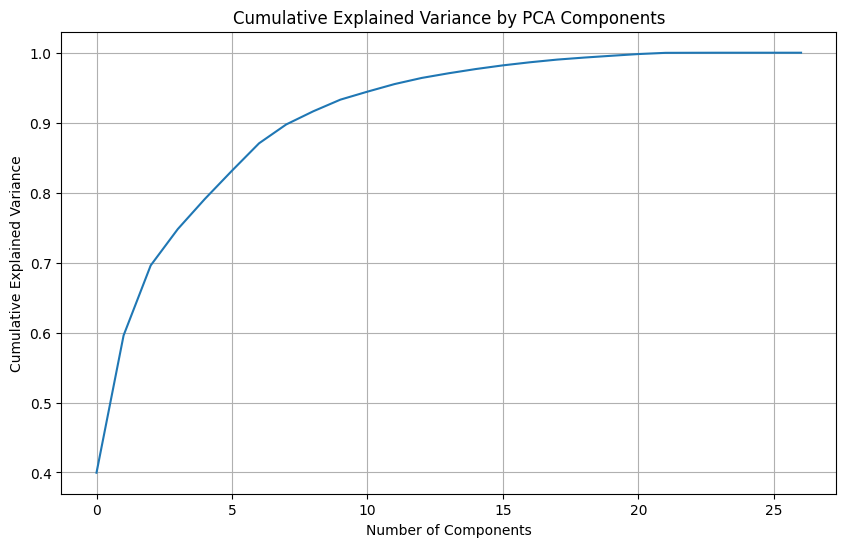


Number of components explaining 95% variance: 12
Shape of original data for PCA: (1720, 27)
Shape of PCA transformed data: (1720, 12)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
0,-0.396241,0.468095,-1.043127,-0.434280,-0.979444,-8.490879,2.740396,-0.941699,-0.783248,-0.382787,-0.861980,-0.200773
1,-0.292047,0.375566,-1.056877,-0.584663,-1.045566,-8.446034,2.829329,-1.033379,-0.751131,-0.526515,-0.999843,0.025809
2,-0.347051,0.427186,-1.060067,-0.512026,-1.012668,-8.465946,2.787577,-0.989668,-0.769583,-0.457363,-0.937634,-0.087018
3,-0.326815,0.414765,-1.083633,-0.554731,-1.029524,-8.449714,2.815241,-1.016845,-0.766342,-0.498718,-0.985546,-0.029445
4,-0.346530,0.388386,-0.836937,-0.160771,-0.159735,-1.769593,0.520421,-0.487931,-0.570424,-0.285978,-0.566879,0.006069


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
data_scaled = scaler.fit_transform(data_pca)

# Initialize PCA
# We can start by keeping all components to observe explained variance, or specify n_components
pca = PCA()

# Fit PCA on the scaled data
pca.fit(data_scaled)

# Display the explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio of each component:")
print(explained_variance_ratio)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Based on the plot, we can decide on the number of components to retain.
# For now, let's keep a number of components that explain a significant portion (e.g., 95%) of the variance.
# Find number of components for 95% variance
n_components_95 = np.where(np.cumsum(explained_variance_ratio) >= 0.95)[0][0] + 1
print(f"\nNumber of components explaining 95% variance: {n_components_95}")

# Re-run PCA with the selected number of components
pca_final = PCA(n_components=n_components_95)
data_pca_transformed = pca_final.fit_transform(data_scaled)

# Display the shape of the transformed data
print(f"Shape of original data for PCA: {data_pca.shape}")
print(f"Shape of PCA transformed data: {data_pca_transformed.shape}")

# Create a DataFrame from the transformed data for easier use
pca_columns = [f'PC_{i+1}' for i in range(n_components_95)]
data_pca_df = pd.DataFrame(data_pca_transformed, columns=pca_columns)
display(data_pca_df.head())

### K-Means Clustering on PCA-Transformed Data

Now that the data has been reduced in dimensionality using PCA, we can apply a clustering algorithm like K-Means to identify natural groupings within the data. For demonstration, we'll choose an arbitrary number of clusters (e.g., 3), but in a real-world scenario, you would typically use methods like the Elbow Method or Silhouette Score to determine the optimal number of clusters (`k`).

In [13]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the elbow method (optional, for choosing k)
# inertia = []
# for k in range(1, 11): # Test k from 1 to 10
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(data_pca_df)
#     inertia.append(kmeans.inertia_)

# plt.figure(figsize=(10, 6))
# plt.plot(range(1, 11), inertia, marker='o')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.title('Elbow Method for Optimal k')
# plt.xticks(range(1, 11))
# plt.grid(True)
# plt.show()

# Based on the plot (or an assumed optimal k), choose the number of clusters.
# For this example, let's choose k=3 as a starting point.
k_clusters = 3

# Initialize and fit KMeans
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10) # n_init suppresses a warning
kmeans.fit(data_pca_df)

# Add the cluster labels to the PCA DataFrame
data_pca_df['Cluster'] = kmeans.labels_

# Display the first few rows with the new cluster labels
print(f"\nData with {k_clusters} K-Means Clusters:")
display(data_pca_df.head())


Data with 3 K-Means Clusters:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,Cluster
0,-0.396241,0.468095,-1.043127,-0.434280,-0.979444,-8.490879,2.740396,-0.941699,-0.783248,-0.382787,-0.861980,-0.200773,1
1,-0.292047,0.375566,-1.056877,-0.584663,-1.045566,-8.446034,2.829329,-1.033379,-0.751131,-0.526515,-0.999843,0.025809,1
2,-0.347051,0.427186,-1.060067,-0.512026,-1.012668,-8.465946,2.787577,-0.989668,-0.769583,-0.457363,-0.937634,-0.087018,1
3,-0.326815,0.414765,-1.083633,-0.554731,-1.029524,-8.449714,2.815241,-1.016845,-0.766342,-0.498718,-0.985546,-0.029445,1
4,-0.346530,0.388386,-0.836937,-0.160771,-0.159735,-1.769593,0.520421,-0.487931,-0.570424,-0.285978,-0.566879,0.006069,1


### Visualizing Clusters (2D Projection)

Although the data is in 12 dimensions, we can visualize the clusters by plotting the first two principal components (PC1 and PC2) and coloring the points by their assigned cluster. This gives a simplified view of the clustering results.

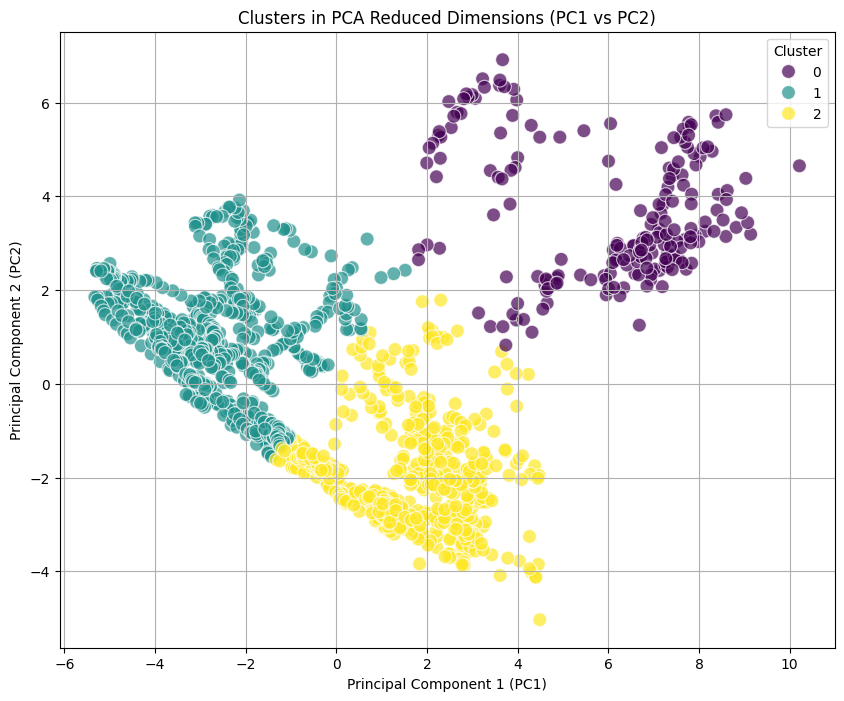

In [14]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC_1',
    y='PC_2',
    hue='Cluster',
    data=data_pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Clusters in PCA Reduced Dimensions (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

### Prepare Data for Train-Test Split

To perform a train-test split, we need to define our features (X) and our target variable (y). We will use the PCA-transformed data (`data_pca_df`) as our features. For the target, we will assume 'Dengue Case' from the original dataset. It's important to align these correctly and handle any missing values in the target variable.

First, we'll merge the 'Dengue Case' column from the original `data` DataFrame to `data_pca_df`. We need to ensure that the indices are aligned correctly. Since `data_pca_df` was created from `data_pca` which in turn was a copy of `data` with some columns dropped and NaNs filled, their indices should already match, but we will explicitly align them.

Next, we'll drop any rows where the 'Dengue Case' is missing, as these cannot be used for supervised learning.

In [15]:
# Merge 'Dengue Case' from the original 'data' DataFrame into 'data_pca_df'
# Ensure alignment by index
data_for_split = data_pca_df.copy()
# Drop the 'Cluster' column as it was generated from the PCA data and is not part of the original features
data_for_split = data_for_split.drop(columns=['Cluster'])

# Get 'Dengue Case' from the original data, ensuring index alignment
data_for_split['Dengue Case'] = data['Dengue Case']

# Drop rows where 'Dengue Case' is NaN (missing target variable)
initial_rows = len(data_for_split)
data_for_split.dropna(subset=['Dengue Case'], inplace=True)
print(f"Dropped {initial_rows - len(data_for_split)} rows with missing 'Dengue Case'.")

# Define features (X) and target (y)
X = data_for_split.drop(columns=['Dengue Case'])
y = data_for_split['Dengue Case']

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Display the head of X and y to confirm
print("\nFeatures (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Dropped 9 rows with missing 'Dengue Case'.

Shape of features (X): (1711, 12)
Shape of target (y): (1711,)

Features (X) head:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
0,-0.396241,0.468095,-1.043127,-0.434280,-0.979444,-8.490879,2.740396,-0.941699,-0.783248,-0.382787,-0.861980,-0.200773
1,-0.292047,0.375566,-1.056877,-0.584663,-1.045566,-8.446034,2.829329,-1.033379,-0.751131,-0.526515,-0.999843,0.025809
2,-0.347051,0.427186,-1.060067,-0.512026,-1.012668,-8.465946,2.787577,-0.989668,-0.769583,-0.457363,-0.937634,-0.087018
3,-0.326815,0.414765,-1.083633,-0.554731,-1.029524,-8.449714,2.815241,-1.016845,-0.766342,-0.498718,-0.985546,-0.029445
4,-0.346530,0.388386,-0.836937,-0.160771,-0.159735,-1.769593,0.520421,-0.487931,-0.570424,-0.285978,-0.566879,0.006069



Target (y) head:


,Dengue Case
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Perform Train-Test Split

Now we will split the dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. A common split ratio is 80% for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

# Perform the train-test split
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
# Removed stratify=y as 'Dengue Case' is a continuous variable, not categorical.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Display the distribution of the target variable in training and testing sets
print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True).sort_index().head())
print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True).sort_index().head())

Shape of X_train: (1368, 12)
Shape of X_test: (343, 12)
Shape of y_train: (1368,)
Shape of y_test: (343,)

Target distribution in y_train:
Dengue Case
0.0    0.757310
1.0    0.047515
2.0    0.032164
3.0    0.019006
4.0    0.009503
Name: proportion, dtype: float64

Target distribution in y_test:
Dengue Case
0.0    0.723032
1.0    0.061224
2.0    0.032070
3.0    0.026239
4.0    0.023324
Name: proportion, dtype: float64


### Train a Decision Tree Classifier

Now that the data is split, we can train a machine learning model. We'll use a `DecisionTreeClassifier` as imported earlier. After training, we'll make predictions on the test set.

In [18]:
# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


### Make Predictions and Evaluate with Confusion Matrix

With the model trained, we can now use it to make predictions on the test set (`X_test`). Then, we'll compare these predictions to the actual values (`y_test`) to evaluate the model's performance using a confusion matrix.

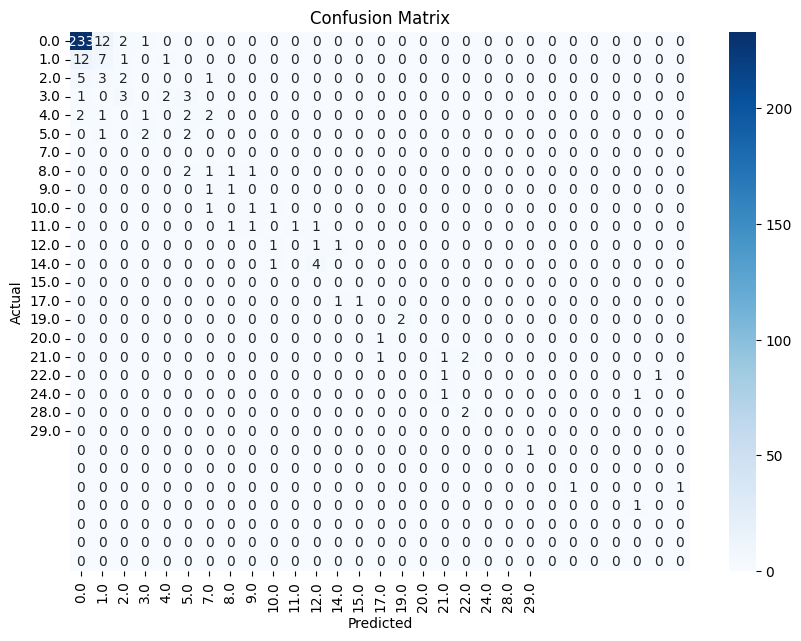

In [19]:
# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()